In [1]:
!pip install faiss-cpu

In [2]:
from tqdm import tqdm, tnrange, tqdm_notebook
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import pickle
import json
import gdown
import h5py
import faiss

%matplotlib inline

# Seminar 6: kNN index and quantization

## 1. Load embeddings

In [3]:
file_id = '1-1t1sbQXXyB-qZr-czqv2UJ4E5BQ7McI'
destination = 'lastftm_factors.h5'
download_url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(download_url, destination, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1-1t1sbQXXyB-qZr-czqv2UJ4E5BQ7McI
From (redirected): https://drive.google.com/uc?id=1-1t1sbQXXyB-qZr-czqv2UJ4E5BQ7McI&confirm=t&uuid=c2904779-66b3-4c70-b133-25c4a65fef6d
To: /Users/naumov-vladis/Desktop/courses/recsys/seminar_08_highload/lastftm_factors.h5
100%|██████████| 333M/333M [00:33<00:00, 10.0MB/s] 


'lastftm_factors.h5'

In [4]:
h5f = h5py.File('lastftm_factors.h5', 'r')
item_factors = h5f['items'][:]
user_factors = h5f['users'][:]
h5f.close()

In [5]:
item_factors.shape

(292385, 128)

In [6]:
user_factors.shape

(358868, 128)

## 2. Neighbours search with FAISS

[Faiss docs](https://faiss.ai/)

In [7]:
%%time
ip_index = faiss.IndexFlatIP(item_factors.shape[1]) # Create index Exact Search for Inner Product

ip_index.add(item_factors) # Add document embeddings to index
print(ip_index.ntotal)

292385
CPU times: user 12.8 ms, sys: 95.8 ms, total: 109 ms
Wall time: 276 ms


In [8]:
k = 50  # Choose 10 nearest neighbours
n_users = 100  # 1000 users is real example of request batch

user_embeddings = user_factors[:n_users]

In [9]:
%%timeit
# D - distances
# I - indices
dist_brute, index_brute = ip_index.search(user_embeddings, k)

36 ms ± 1.49 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [10]:
dist_brute, index_brute = ip_index.search(user_embeddings, k)

In [11]:
dist_brute[:10]

array([[1.1410543 , 1.1322321 , 1.1187365 , 1.0928438 , 1.0664618 ,
        1.062733  , 1.05291   , 1.0320057 , 1.0301973 , 1.0179089 ,
        1.0020028 , 0.9837904 , 0.98047704, 0.9796851 , 0.96542853,
        0.9620888 , 0.95902544, 0.9556296 , 0.9555267 , 0.95469624,
        0.95193106, 0.95178026, 0.9506871 , 0.9500801 , 0.94741666,
        0.9468063 , 0.93974173, 0.92981064, 0.9231755 , 0.92246383,
        0.91976446, 0.9178443 , 0.91715044, 0.9113436 , 0.90982354,
        0.9073585 , 0.90652895, 0.9046614 , 0.90354747, 0.90326846,
        0.89783937, 0.89204746, 0.891694  , 0.8910956 , 0.8886769 ,
        0.88656265, 0.8863777 , 0.88404644, 0.8812577 , 0.8803741 ],
       [1.2508918 , 1.249527  , 1.2257144 , 1.2112938 , 1.1923635 ,
        1.189894  , 1.1788456 , 1.1644775 , 1.1519464 , 1.1518093 ,
        1.1348926 , 1.1333601 , 1.131854  , 1.1168416 , 1.1018484 ,
        1.0981128 , 1.0895374 , 1.088695  , 1.0817112 , 1.0800222 ,
        1.0795983 , 1.0732406 , 1.0706415 , 1.0

In [12]:
index_brute[:10]

array([[150177, 161850, 107119, 144310,  76757, 255141, 155259,  46258,
        136336, 259874, 255068, 275919, 255226, 217076,  90705, 137079,
        254099, 165938, 155258, 199287,   4580,  35023, 111603, 272757,
        185384, 165137, 116827, 230026,  37529,  45575, 140710, 249555,
          3416,  98993, 205631, 164039, 201166,  50610, 219096, 168138,
        249560, 129399, 228777,  48292, 175819, 252787, 110905, 168137,
        245502,  12537],
       [186566,  86649,  71465,  78295, 229823,  54967, 189597, 252956,
        250342, 267949,  71225,  86665,  50365, 155806, 255779, 262990,
        125452, 261137, 274818, 208011, 128505, 248849,  26278, 214351,
        235136, 219131, 116919,  32593,  56783, 186441, 111764,  27873,
        176605,  56308, 117795, 257566, 242523, 190802,  75756, 263348,
        176709,  53756,  33246,  53846,  68513, 258362,  54515, 262555,
        266344, 192736],
       [180940, 142885, 120981,  37629,  78810, 166647, 159270, 234769,
        241312

In [13]:
dist_brute.shape

(100, 50)

Let's compare with vanilla method to find nearest neighbours:

In [14]:
# too long because we sort full array
product = user_embeddings.dot(item_factors.T)
exact_indexes = np.argsort(product, axis=1)[:,:-k-1:-1]

In [15]:
%%time
product = user_embeddings.dot(item_factors.T)
neighbours = np.partition(-1 * product, k, axis=1)[:, :k]
exact_distances = -1 * np.sort(neighbours, axis=1)

CPU times: user 1.38 s, sys: 1.16 s, total: 2.53 s
Wall time: 415 ms


In [16]:
np.allclose(dist_brute, exact_distances)

True

In [17]:
np.equal(index_brute, exact_indexes).mean()

1.0

## 3. HNSW

<img src="images/hnsw.png" alt="drawing" width="500"/>

**HNSW** (Hierarchical navigable small world) - graph-based approximate nearest neighbor algorithm.

In [18]:
%%time
neighbours = 50


hnsw_index = faiss.IndexHNSWFlat(item_factors.shape[1], neighbours, faiss.METRIC_INNER_PRODUCT) # Create HNSW index

hnsw_index.hnsw.efSearch = 1600
hnsw_index.hnsw.m = 96
hnsw_index.hnsw.efConstruction = 1000

faiss.normalize_L2(item_factors)
hnsw_index.add(item_factors)


CPU times: user 6min 55s, sys: 14.6 s, total: 7min 10s
Wall time: 57.7 s


In [19]:
%%time
dist_hnsw, index_hnsw = hnsw_index.search(user_embeddings, k)

CPU times: user 445 ms, sys: 9.09 ms, total: 454 ms
Wall time: 55.6 ms


In [20]:
%%time
# too long because we sort full array
product = user_embeddings.dot(item_factors.T)
exact_indexes = np.argsort(product, axis=1)[:,:-k-1:-1]

CPU times: user 3.12 s, sys: 1.6 s, total: 4.72 s
Wall time: 2.45 s


In [21]:
index_hnsw[:1]

array([[163197, 251773,  18748, 203356, 259874, 112589, 201943,  45575,
        275850, 288601,  62309,   5322,  70526, 253506, 138228,  65428,
        236277,  14673, 145233, 254099,   4580, 164482, 262401,  85321,
        186493, 249989,  63381, 111282,  59325, 186026,  98049, 151174,
        254338,  41017,  91144,  32782,  35176, 283940,  86698, 272362,
         99683, 171267,  50610, 158124, 201166,  45568, 105929, 161501,
        206361,   8618]])

In [22]:
dist_hnsw[:1]

array([[9.957334 , 9.653418 , 9.609158 , 9.540543 , 9.3876915, 9.332269 ,
        9.272761 , 9.258059 , 9.225113 , 9.214385 , 9.173319 , 8.954049 ,
        8.887031 , 8.864248 , 8.8621025, 8.79291  , 8.771091 , 8.767221 ,
        8.739708 , 8.651405 , 8.616868 , 8.601856 , 8.596088 , 8.523359 ,
        8.512981 , 8.511211 , 8.505213 , 8.464906 , 8.450711 , 8.438484 ,
        8.370792 , 8.305387 , 8.302201 , 8.250094 , 8.237274 , 8.203122 ,
        8.162452 , 8.142109 , 8.140545 , 8.110386 , 8.069276 , 8.034339 ,
        8.027824 , 8.025734 , 7.978615 , 7.9185123, 7.914952 , 7.9139476,
        7.910552 , 7.8855906]], dtype=float32)

In [23]:
np.equal(index_hnsw, exact_indexes).mean()

0.9812

Algorithm is not tuned for the dataset, so results are not the best. But you can find optimal parameters for 99% or even 99.9%.

## Extra: Nearest neighbours using KDTree

In [24]:
from sklearn.neighbors import KDTree

In [26]:
tree = KDTree(item_factors, leaf_size=5)              
dist_kd, ind_kd = tree.query(user_embeddings, k=k)                
print(ind_kd)

[[163197 251773  18748 ... 161501 206361   8618]
 [187610 246138  13544 ... 184715 261870 140707]
 [133871 223203  24014 ...  85163 196410 117829]
 ...
 [139982  72580 166334 ... 222646  50417  25495]
 [207501  51965 151438 ...  44147  24664 158761]
 [186242  45911  96262 ... 266535  33604  94169]]


In [27]:
np.equal(ind_kd, exact_indexes).mean()

1.0

## 4. Quantization

<img src="images/quant.png" alt="drawing" width="800"/>

In [28]:
# first coordinates of item embeddings
item_factors[:, 0]

array([0.02977079, 0.0655965 , 0.11125812, ..., 0.01040033, 0.06758923,
       0.11998597], dtype=float32)

Let's look at distribution of first coordinates:

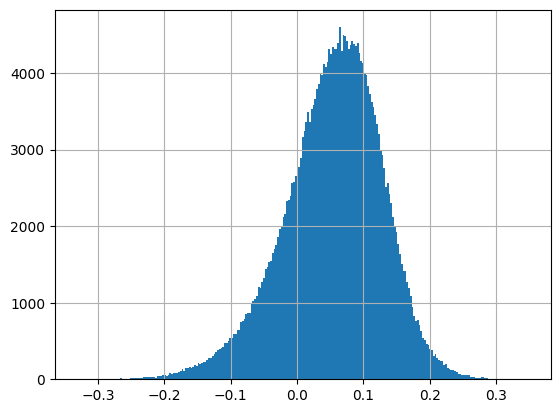

In [29]:
plt.hist(item_factors[:, 0], bins=255)
plt.grid()
plt.show()

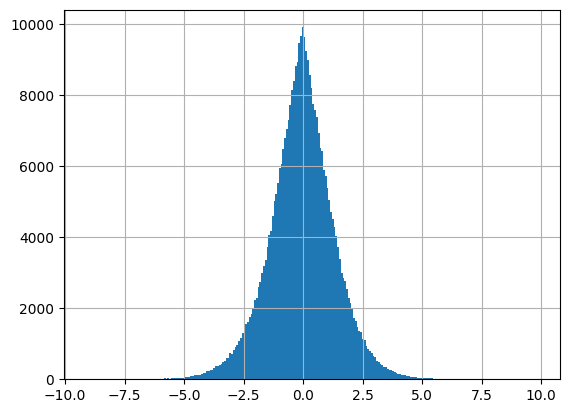

In [30]:
plt.hist(user_factors[:, 0], bins=255)
plt.grid()
plt.show()

### a. Percentile quantizations

**Steps:**
1. **Compute Percentiles**:  
   Divide the embedding values into \(k\) bins (e.g., 256) by calculating percentile values for each dimension.

2. **Quantization**:  
   Map each value in the embeddings to its corresponding bin. Clip the bin indices to the range \([0, k-1]\).

3. **Restoration**:  
   Approximate the original values by replacing each quantized bin index with its corresponding percentile value.


Firstly, let's do it for **items**:

In [31]:
item_factors.shape

(292385, 128)

In [32]:
# sample.shape

In [33]:
# sample_indexes

In [34]:
sample_size = 100_000
item_percentiles = []
quanitles = np.linspace(0, 100, 256)

sample_indexes = np.random.randint(len(item_factors), size=sample_size)
sample = item_factors[sample_indexes]

thesholds = np.percentile(sample, quanitles, axis=0)
thesholds.shape

(256, 128)

In [35]:
thesholds

array([[-0.32885885, -0.27651826, -0.33932415, ..., -0.36812624,
        -0.30789062, -0.33767548],
       [-0.17781981, -0.16750197, -0.16531878, ..., -0.1671968 ,
        -0.16460164, -0.16317968],
       [-0.1540581 , -0.14468685, -0.14434403, ..., -0.14593201,
        -0.14109107, -0.14010629],
       ...,
       [ 0.21636985,  0.21745835,  0.22898204, ...,  0.21181245,
         0.21830483,  0.21532953],
       [ 0.23266905,  0.23336415,  0.25342335, ...,  0.22598952,
         0.23511183,  0.2334605 ],
       [ 0.34864619,  0.36445111,  0.35090804, ...,  0.34616891,
         0.38440207,  0.33123234]])

In [36]:
item_percentiles = np.vstack(thesholds)

In [37]:
def perc_quantize(v, percentiles):
    res = []
    for i in range(v.shape[1]):
        res.append(np.digitize(v[:, i], percentiles[:, i]))
    res = np.vstack(res).T
    res = np.clip(res, 0, 255)
    return res

In [38]:
def perc_restore(q, percentiles):
    res = []
    for i in range(q.shape[1]):
        res.append(percentiles[q[:, i], i])
    return np.vstack(res).T

(-0.01, 0.02)

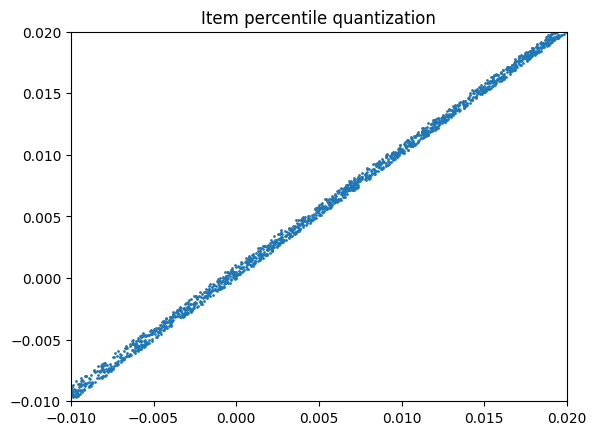

In [39]:
# ideal plot: y = x
restored_vectors = perc_restore(perc_quantize(item_factors[:100, :], item_percentiles), item_percentiles)
plt.scatter(item_factors[:100, :], restored_vectors, s=1)
plt.title("Item percentile quantization")
plt.xlim(-0.01, 0.02)
plt.ylim(-0.01, 0.02)

And for **users**:

In [41]:
N = 100000
user_percentiles = []
for perc in tqdm(np.linspace(0, 100, 256)):
    user_percentiles.append(np.percentile(user_factors[:N, :], perc, axis=0))

100%|██████████| 256/256 [01:06<00:00,  3.84it/s]


In [42]:
user_percentiles = np.vstack(user_percentiles)

(-4.0, 4.0)

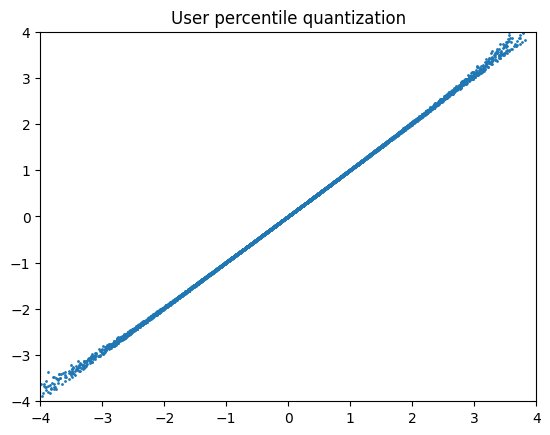

In [43]:
# ideal plot: y = x
plt.scatter(user_factors[:100, :], perc_restore(perc_quantize(user_factors[:100, :], user_percentiles), user_percentiles), s=1)
plt.title("User percentile quantization")

plt.xlim(-4, 4)
plt.ylim(-4, 4)

Then we can check the overlap of quantized embeddings and original embeddings:

In [44]:
overlaps = []
for user_idx in tqdm(range(1, N, int(N/100))):
    scores1 = item_factors[:N].dot(user_factors[user_idx, :])
    scores2 = item_factors[:N].dot(
        perc_restore(
            perc_quantize(user_factors[user_idx:user_idx+1, :], user_percentiles),
            user_percentiles)[0])
    order1 = np.argsort(scores1)[::-1][:100]
    order2 = np.argsort(scores2)[::-1][:100]
    overlaps.append(len(set(order1) & set(order2)))
print("MEAN:", np.mean(overlaps))

100%|██████████| 100/100 [00:07<00:00, 12.77it/s]

MEAN: 94.37


### b. MinMax quantization

**Steps:**
1. **Range:**
   
   First, determine the range of values by calculating the 1st and 99th percentiles of the embedding values. These percentiles represent the lower and upper bounds of the data, respectively, and they define the range over which the data will be quantized.

2. **Quantize:**
   
   The quantization process scales the embedding values to a [0, 255] range. This is done by first normalizing the data within the defined range, then scaling it to fit the target range (0 to 255). Any values outside the range are clipped to ensure they fall within the [0, 255] bounds.

3. **Restore:**
   
   After quantization, the original values can be restored by reversing the scaling process. The quantized values are multiplied by a scaling factor and then shifted back by the lower bound. This restores the values to a continuous range similar to the original data.

**Quantization:** $q(x) = \frac{x - min}{max - min} \cdot 256$

**Restore:** $q^{-1}(x) = \frac{x(max - min)}{256} + min$


Let's start for **items**:

In [45]:
item_low = np.percentile(item_factors[:N], 1, axis=0)
item_high = np.percentile(item_factors[:N], 99, axis=0)

item_step = (item_high - item_low + 1e-6) / 255.

In [46]:
def mm_quantize(value, low, high):
    return (np.minimum(np.maximum((value - low) / (high - low + 1e-6), 0), 1) * 255).astype(np.uint8)

def mm_restore(q, l, s):
    return q.astype(np.float32) * s + l

(-0.01, 0.02)

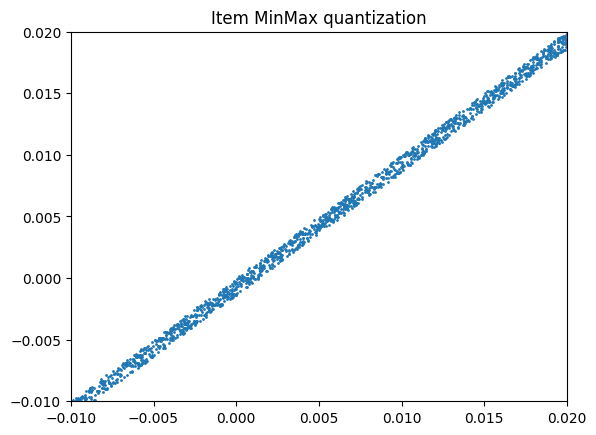

In [47]:
plt.scatter(item_factors[0:100, :], mm_restore(mm_quantize(item_factors[0:100, :], item_low, item_high), item_low, item_step), s=1)
plt.title("Item MinMax quantization")

plt.xlim(-0.01, 0.02)
plt.ylim(-0.01, 0.02)

In [48]:
overlaps = []
boo = mm_restore(mm_quantize(item_factors[:N], item_low, item_high), item_low, item_step)
for user_idx in range(1, N, int(N / 100)):
    scores1 = item_factors[:N].dot(user_factors[user_idx, :])
    scores2 = boo.dot(user_factors[user_idx, :])
    order1 = np.argsort(scores1)[::-1][:100]
    order2 = np.argsort(scores2)[::-1][:100]
    overlaps.append(len(set(order1) & set(order2)))
print("MEAN:", np.mean(overlaps))

MEAN: 92.24


And for **users**:

In [49]:
user_low = np.percentile(user_factors[:N], 1, axis=0)
user_high = np.percentile(user_factors[:N], 99, axis=0)

user_step = (user_high - user_low + 1e-6) / 255.

(-4.0, 4.0)

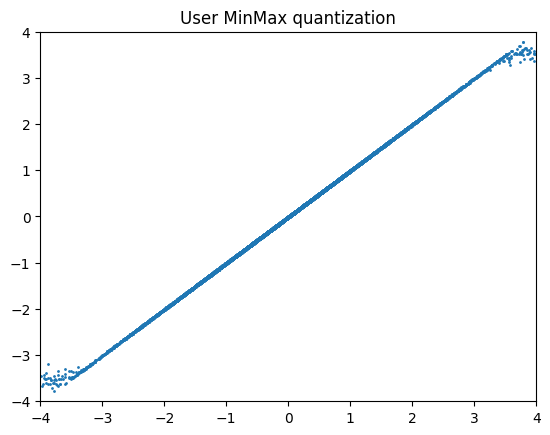

In [50]:
plt.scatter(user_factors[0:100, :], mm_restore(mm_quantize(user_factors[0:100, :], user_low, user_high), user_low, user_step), s=1)
plt.title("User MinMax quantization")

plt.xlim(-4, 4)
plt.ylim(-4, 4)

In [51]:
overlaps = []
for user_idx in range(1, N, int(N/100)):
    scores1 = item_factors[:N].dot(user_factors[user_idx, :])
    scores2 = item_factors[:N].dot(
        mm_restore(
            mm_quantize(user_factors[user_idx:user_idx+1, :], user_low, user_high),
            user_low, user_step)[0])
    order1 = np.argsort(scores1)[::-1][:100]
    order2 = np.argsort(scores2)[::-1][:100]
    overlaps.append(len(set(order1) & set(order2)))
print( "MEAN:", np.mean(overlaps))

MEAN: 96.39
